# Seed07 UMAP Visualization

This notebook reviews the saved Seed07 pseudo-label UMAP artifacts and recreates the plots inline.

Recommended order:
- confirm the `seed07` branch-local artifacts already exist
- leave `RUN_UMAP_EXPORTS = False` to stay in artifact-review mode
- optionally set `RUN_UMAP_EXPORTS = True` if you want to regenerate the UMAP CSVs and summaries
- run the plotting cells to render the figures inline and save fresh PNGs under this notebook's `artifacts/` folder


In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
REPO_ROOT = None
for candidate in candidate_roots:
    if (candidate / "src" / "wafer_defect").exists() and (candidate / "configs").exists():
        REPO_ROOT = candidate
        break

if REPO_ROOT is None:
    raise RuntimeError("Could not locate repo root containing src/wafer_defect and configs/")

SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

NOTEBOOK_DIR = REPO_ROOT / "experiments/classifier/multiclass/x64/umap"
SEED07_DIR = NOTEBOOK_DIR.parent / "seed07"

from wafer_defect.config import load_toml


In [2]:
data_config_path = SEED07_DIR / "data_config.toml"
train_config_path = SEED07_DIR / "train_config.toml"
data_config = load_toml(data_config_path)
train_config = load_toml(train_config_path)

seed07_artifact_dir = SEED07_DIR / "artifacts" / Path(train_config["training"]["output_dir"]).name
checkpoint_path = seed07_artifact_dir / "best_model.pt"
unlabeled_predictions_path = seed07_artifact_dir / "unlabeled_predictions.csv"

artifact_root = NOTEBOOK_DIR / "artifacts"
legacy_artifact_root = NOTEBOOK_DIR / "upload_artifacts"
visualization_dir = artifact_root / "umap_visualization"
ten_a_dir = artifact_root / "umap_10a_style"
visualization_dir.mkdir(parents=True, exist_ok=True)
ten_a_dir.mkdir(parents=True, exist_ok=True)

RUN_UMAP_EXPORTS = False


def resolve_artifact(relative_path: str) -> Path:
    relative = Path(relative_path)
    for root in (artifact_root, legacy_artifact_root):
        candidate = root / relative
        if candidate.exists():
            return candidate
    return artifact_root / relative


labeled_reference_csv_path = resolve_artifact("umap_visualization/labeled_reference_umap.csv")
pseudo_label_csv_path = resolve_artifact("umap_visualization/pseudo_label_umap.csv")
visualization_summary_path = resolve_artifact("umap_visualization/seed07_pseudolabel_umap.summary.json")

ten_a_points_csv_path = resolve_artifact("umap_10a_style/embedding_umap_points_10a_style.csv")
ten_a_summary_path = resolve_artifact("umap_10a_style/umap_10a_style.summary.json")

standard_plot_path = visualization_dir / "seed07_pseudolabel_umap.png"
split_plot_path = ten_a_dir / "umap_by_split_10a_style.png"
score_plot_path = ten_a_dir / "umap_by_score_10a_style.png"
pseudo_plot_path = ten_a_dir / "umap_by_pseudo_label_10a_style.png"

required_seed07_paths = [checkpoint_path, unlabeled_predictions_path]
missing_seed07_paths = [path for path in required_seed07_paths if not path.exists()]
if missing_seed07_paths:
    raise FileNotFoundError(
        "Missing required Seed07 artifacts:\n" + "\n".join(str(path) for path in missing_seed07_paths)
    )

print("Data config:", data_config_path)
print("Train config:", train_config_path)
print("Seed07 artifact dir:", seed07_artifact_dir)
print("UMAP artifact root:", artifact_root)
print("Legacy UMAP artifact root:", legacy_artifact_root)
print("Run UMAP exports:", RUN_UMAP_EXPORTS)


Data config: C:\Users\genso\Documents\College_Projects\DeepLearning 2610\Project\experiments\classifier\multiclass\x64\seed07\data_config.toml
Train config: C:\Users\genso\Documents\College_Projects\DeepLearning 2610\Project\experiments\classifier\multiclass\x64\seed07\train_config.toml
Seed07 artifact dir: C:\Users\genso\Documents\College_Projects\DeepLearning 2610\Project\experiments\classifier\multiclass\x64\seed07\artifacts\multiclass_classifier_all_80_10_10_seed07
UMAP artifact root: C:\Users\genso\Documents\College_Projects\DeepLearning 2610\Project\experiments\classifier\multiclass\x64\umap\artifacts
Legacy UMAP artifact root: C:\Users\genso\Documents\College_Projects\DeepLearning 2610\Project\experiments\classifier\multiclass\x64\umap\upload_artifacts
Run UMAP exports: False


In [3]:
if RUN_UMAP_EXPORTS:
    export_commands = [
        [
            sys.executable,
            str(REPO_ROOT / "scripts/classifier/export_seed07_pseudolabel_umap.py"),
            "--config",
            str(data_config_path),
            "--checkpoint",
            str(checkpoint_path),
            "--pseudo-label-csv",
            str(unlabeled_predictions_path),
            "--output-dir",
            str(visualization_dir),
        ],
        [
            sys.executable,
            str(REPO_ROOT / "scripts/classifier/export_seed07_pseudolabel_umap_10a_style.py"),
            "--config",
            str(data_config_path),
            "--checkpoint",
            str(checkpoint_path),
            "--pseudo-label-csv",
            str(unlabeled_predictions_path),
            "--output-dir",
            str(ten_a_dir),
        ],
    ]
    for command in export_commands:
        print("Running:", " ".join(command))
        subprocess.run(command, cwd=REPO_ROOT, check=True)
else:
    print("RUN_UMAP_EXPORTS is False. Reusing saved CSV artifacts when available.")


RUN_UMAP_EXPORTS is False. Reusing saved CSV artifacts when available.


In [4]:
required_plot_inputs = [
    labeled_reference_csv_path,
    pseudo_label_csv_path,
    ten_a_points_csv_path,
]
missing_plot_inputs = [path for path in required_plot_inputs if not path.exists()]
if missing_plot_inputs:
    raise FileNotFoundError(
        "Missing required UMAP CSV artifacts:\n" + "\n".join(str(path) for path in missing_plot_inputs)
    )

labeled_reference_umap = pd.read_csv(labeled_reference_csv_path)
pseudo_label_umap = pd.read_csv(pseudo_label_csv_path)
ten_a_umap_points = pd.read_csv(ten_a_points_csv_path)

visualization_summary = (
    json.loads(visualization_summary_path.read_text(encoding="utf-8"))
    if visualization_summary_path.exists()
    else None
)
ten_a_summary = (
    json.loads(ten_a_summary_path.read_text(encoding="utf-8"))
    if ten_a_summary_path.exists()
    else None
)

print("Labeled reference points:", len(labeled_reference_umap))
print("Pseudo-label points:", len(pseudo_label_umap))
print("10A-style points:", len(ten_a_umap_points))
if visualization_summary is not None:
    print("Visualization confidence floor:", visualization_summary.get("min_confidence"))
if ten_a_summary is not None:
    print("10A-style PCA dim:", ten_a_summary.get("pca_dim"))

display(labeled_reference_umap.head())
display(pseudo_label_umap.head())
display(ten_a_umap_points.head())


Labeled reference points: 3349
Pseudo-label points: 6865
10A-style points: 16000
Visualization confidence floor: 0.75
10A-style PCA dim: 50


,raw_index,true_label,source_split,umap_x,umap_y
0,589923,Center,Training,9.182100,19.213110
1,394965,Center,Training,11.519553,19.587730
2,724878,Center,Test,8.693539,17.901646
3,274162,Center,Training,10.351663,18.896873
4,524141,Center,Training,10.185511,19.906132


,raw_index,pseudo_label,pseudo_label_confidence,second_choice_label,second_choice_confidence,accepted_for_pseudo_label,umap_x,umap_y
0,276,Edge-Loc,0.939567,none,0.025237,True,-0.300806,8.183593
1,338,Loc,0.842187,Center,0.087461,False,5.108874,10.230241
2,405,Center,0.919183,Loc,0.032122,True,9.633490,17.783707
3,775,Loc,0.940648,Edge-Loc,0.021787,True,3.677705,8.501846
4,925,Edge-Loc,0.968519,Random,0.005465,True,-0.562357,6.086360


,umap_1,umap_2,split_label,score,raw_index,true_label,pseudo_label,pseudo_label_confidence,second_choice_label,second_choice_confidence,accepted_for_pseudo_label
0,10.575911,7.448503,labeled_normal,NaN,798632,none,NaN,NaN,NaN,NaN,NaN
1,8.167589,14.237672,labeled_normal,NaN,731331,none,NaN,NaN,NaN,NaN,NaN
2,11.816892,9.000967,labeled_normal,NaN,776034,none,NaN,NaN,NaN,NaN,NaN
3,7.919223,17.064480,labeled_normal,NaN,712387,none,NaN,NaN,NaN,NaN,NaN
4,9.864396,15.431790,labeled_normal,NaN,777,none,NaN,NaN,NaN,NaN,NaN


In [5]:
def build_palette(labels: list[str]) -> dict[str, tuple[float, float, float, float]]:
    cmap = plt.get_cmap("tab10")
    return {label: cmap(idx % cmap.N) for idx, label in enumerate(labels)}


class_names = sorted(
    set(labeled_reference_umap["true_label"].dropna().astype(str))
    | set(pseudo_label_umap["pseudo_label"].dropna().astype(str))
)
palette = build_palette(class_names)


def save_standard_umap_plot() -> Path:
    fig, axes = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)

    for class_name in class_names:
        label_mask = labeled_reference_umap["true_label"] == class_name
        if label_mask.any():
            axes[0].scatter(
                labeled_reference_umap.loc[label_mask, "umap_x"],
                labeled_reference_umap.loc[label_mask, "umap_y"],
                s=16,
                alpha=0.75,
                color=palette[class_name],
                label=class_name,
            )
    axes[0].set_title("Labeled WM-811K Reference")
    axes[0].set_xlabel("UMAP-1")
    axes[0].set_ylabel("UMAP-2")
    axes[0].grid(alpha=0.2)
    axes[0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

    axes[1].scatter(
        labeled_reference_umap["umap_x"],
        labeled_reference_umap["umap_y"],
        s=8,
        alpha=0.18,
        color="#9ca3af",
        label="Labeled reference",
    )
    for class_name in class_names:
        label_mask = pseudo_label_umap["pseudo_label"] == class_name
        if label_mask.any():
            point_sizes = 12.0 + 26.0 * pseudo_label_umap.loc[label_mask, "pseudo_label_confidence"].to_numpy()
            axes[1].scatter(
                pseudo_label_umap.loc[label_mask, "umap_x"],
                pseudo_label_umap.loc[label_mask, "umap_y"],
                s=point_sizes,
                alpha=0.55,
                color=palette[class_name],
                label=class_name,
            )
    confidence_floor = visualization_summary.get("min_confidence", 0.75) if visualization_summary else 0.75
    axes[1].set_title(f"Pseudo Labels Projected Into Labeled Space (confidence >= {confidence_floor:.2f})")
    axes[1].set_xlabel("UMAP-1")
    axes[1].set_ylabel("UMAP-2")
    axes[1].grid(alpha=0.2)
    axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

    fig.savefig(standard_plot_path, dpi=200, bbox_inches="tight")
    print(f"Saved standard UMAP plot to {standard_plot_path}")
    plt.show()
    plt.close(fig)
    return standard_plot_path


Saved standard UMAP plot to C:\Users\genso\Documents\College_Projects\DeepLearning 2610\Project\experiments\classifier\multiclass\x64\umap\artifacts\umap_visualization\seed07_pseudolabel_umap.png


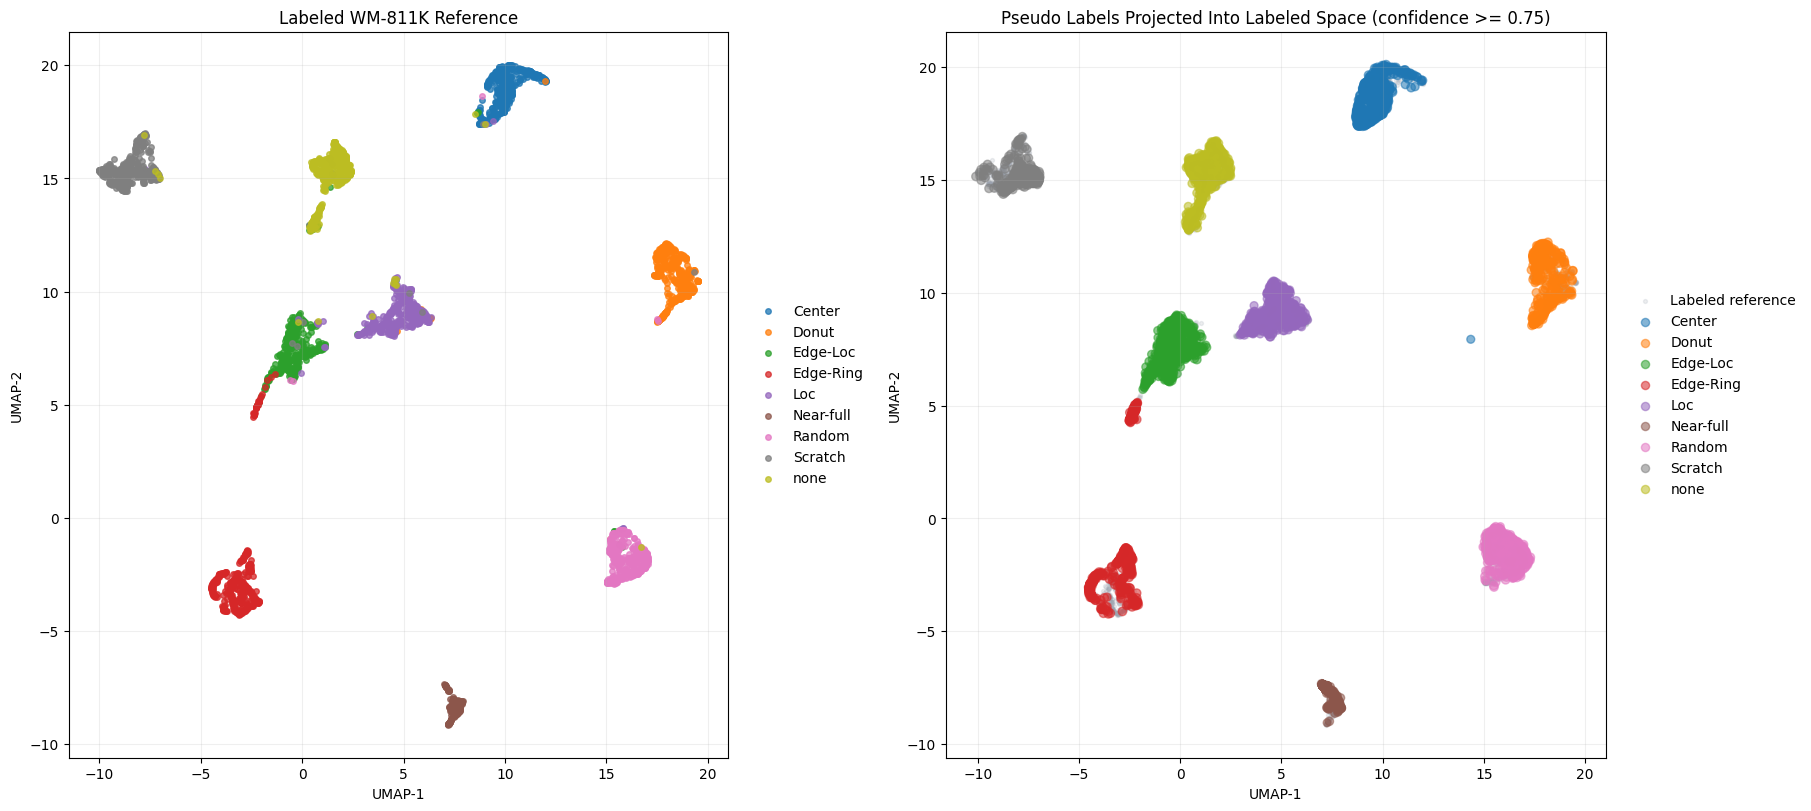

In [6]:
standard_plot_path = save_standard_umap_plot()


In [7]:
def save_split_plot() -> Path:
    fig, ax = plt.subplots(figsize=(10, 7))
    style_map = {
        "labeled_normal": dict(s=10, alpha=0.30, label="labeled_normal", color="#4d908e"),
        "labeled_defect": dict(s=12, alpha=0.50, label="labeled_defect", color="#f3722c"),
        "pseudo_unlabeled": dict(s=14, alpha=0.65, label="pseudo_unlabeled", color="#577590"),
    }

    for split_name, group in ten_a_umap_points.groupby("split_label"):
        plot_style = style_map.get(split_name, dict(s=10, alpha=0.5, label=split_name, color="#6b7280"))
        ax.scatter(group["umap_1"], group["umap_2"], **plot_style)

    ax.set_title("10A-style UMAP of Seed07 Classifier Embeddings")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    fig.savefig(split_plot_path, dpi=200, bbox_inches="tight")
    print(f"Saved split plot to {split_plot_path}")
    plt.show()
    plt.close(fig)
    return split_plot_path


def save_score_plot() -> Path:
    fig, ax = plt.subplots(figsize=(10, 7))
    score_mask = ten_a_umap_points["split_label"] == "pseudo_unlabeled"

    ax.scatter(
        ten_a_umap_points.loc[~score_mask, "umap_1"],
        ten_a_umap_points.loc[~score_mask, "umap_2"],
        s=8,
        alpha=0.12,
        color="#9ca3af",
        label="labeled reference",
    )
    sc = ax.scatter(
        ten_a_umap_points.loc[score_mask, "umap_1"],
        ten_a_umap_points.loc[score_mask, "umap_2"],
        c=ten_a_umap_points.loc[score_mask, "score"],
        cmap="viridis",
        s=18,
        alpha=0.85,
        label="pseudo_unlabeled",
    )
    fig.colorbar(sc, ax=ax, label="pseudo-label confidence")
    ax.set_title("10A-style UMAP Colored by Pseudo-Label Confidence")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    fig.savefig(score_plot_path, dpi=200, bbox_inches="tight")
    print(f"Saved score plot to {score_plot_path}")
    plt.show()
    plt.close(fig)
    return score_plot_path


def save_pseudo_label_plot() -> Path:
    fig, ax = plt.subplots(figsize=(10, 7))
    score_mask = ten_a_umap_points["split_label"] == "pseudo_unlabeled"

    ax.scatter(
        ten_a_umap_points.loc[~score_mask, "umap_1"],
        ten_a_umap_points.loc[~score_mask, "umap_2"],
        s=8,
        alpha=0.10,
        color="#d1d5db",
        label="labeled reference",
    )

    pseudo_palette = plt.get_cmap("tab10")
    pseudo_groups = ten_a_umap_points.loc[score_mask].groupby("pseudo_label", sort=True)
    for idx, (pseudo_label, group) in enumerate(pseudo_groups):
        ax.scatter(
            group["umap_1"],
            group["umap_2"],
            s=18,
            alpha=0.70,
            label=str(pseudo_label),
            color=pseudo_palette(idx % pseudo_palette.N),
        )

    ax.set_title("10A-style UMAP with Pseudo Labels Highlighted")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    fig.savefig(pseudo_plot_path, dpi=200, bbox_inches="tight")
    print(f"Saved pseudo-label plot to {pseudo_plot_path}")
    plt.show()
    plt.close(fig)
    return pseudo_plot_path


Saved split plot to C:\Users\genso\Documents\College_Projects\DeepLearning 2610\Project\experiments\classifier\multiclass\x64\umap\artifacts\umap_10a_style\umap_by_split_10a_style.png


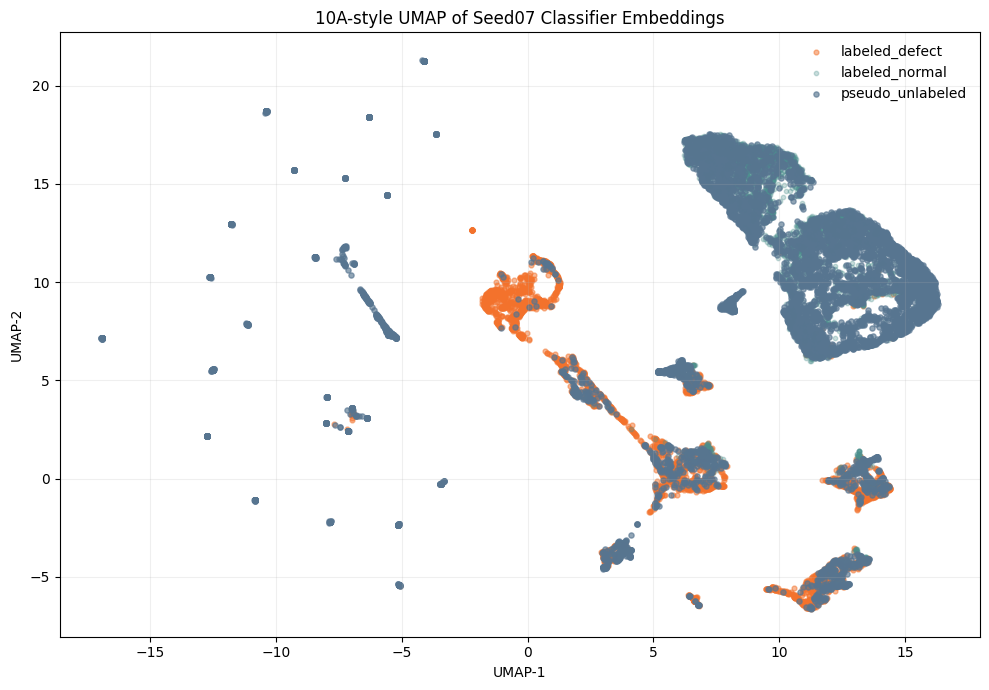

Saved score plot to C:\Users\genso\Documents\College_Projects\DeepLearning 2610\Project\experiments\classifier\multiclass\x64\umap\artifacts\umap_10a_style\umap_by_score_10a_style.png


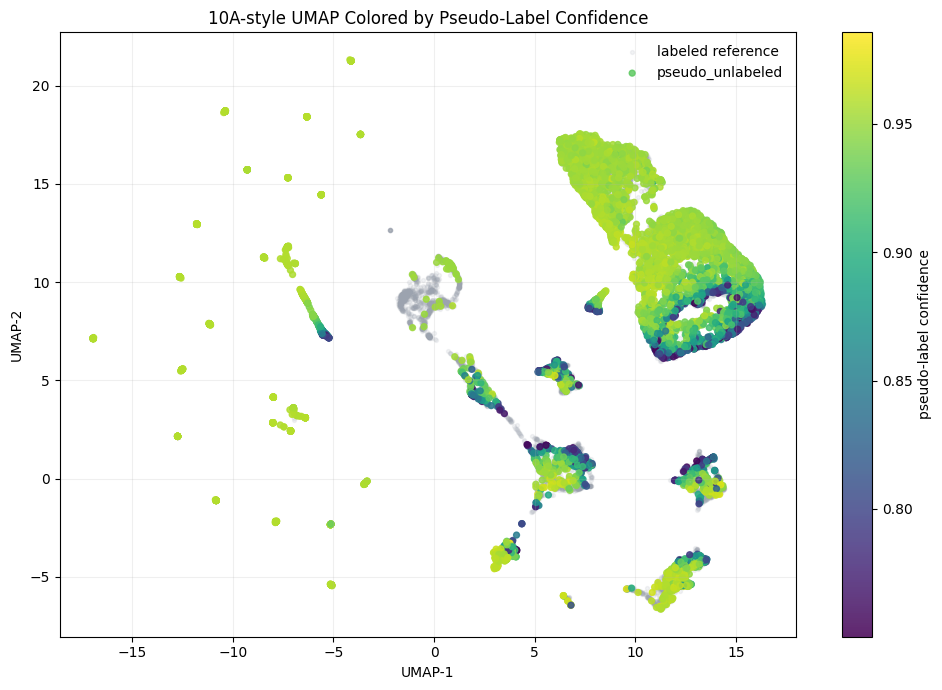

Saved pseudo-label plot to C:\Users\genso\Documents\College_Projects\DeepLearning 2610\Project\experiments\classifier\multiclass\x64\umap\artifacts\umap_10a_style\umap_by_pseudo_label_10a_style.png


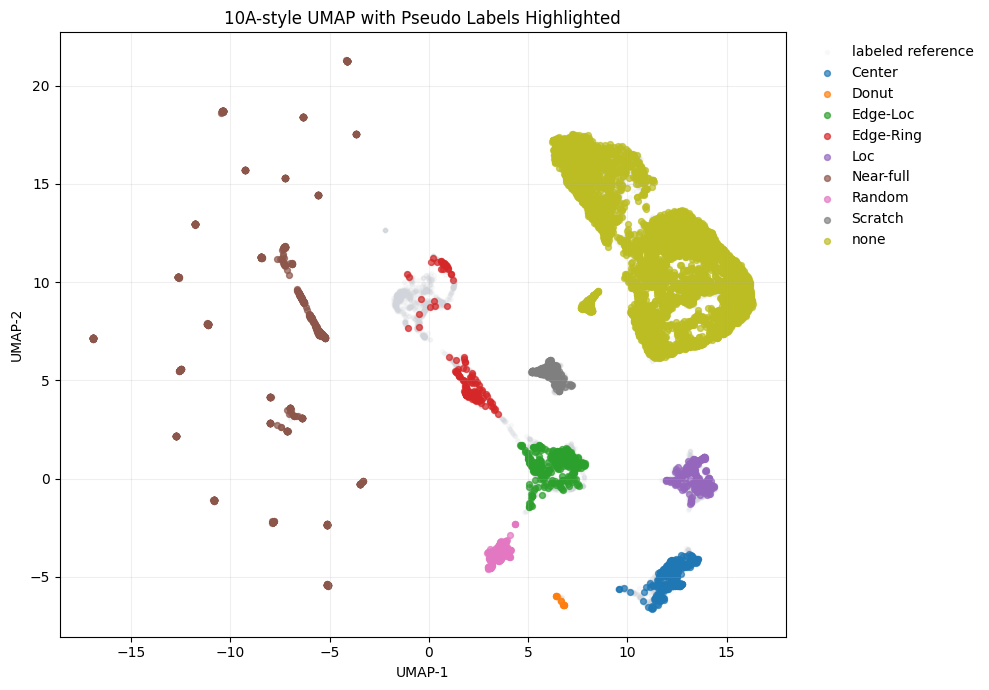

In [8]:
split_plot_path = save_split_plot()
score_plot_path = save_score_plot()
pseudo_plot_path = save_pseudo_label_plot()
